# White-tailed Deer and CWD in North Carolina
This notebook looks at deer sightings, deer harvest, public game lands, and chronic wasting disease (CWD) counties in North Carolina.

Import Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

Load Shapefiles

In [2]:
counties = gpd.read_file("../week07/data/nc_counties/nc_counties.shp")
game_lands = gpd.read_file("../week07/data/gamelands/Game_Lands.shp")

print(counties.crs)
print(game_lands.crs)
counties.head()

EPSG:6543
EPSG:32119


,OBJECTID,County,FIPS,Rec_Survey,NCGS_url,ck_date,Shape__Are,Shape__Len,GlobalID,geometry
0,1,Alamance,001,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13,1.210717e+10,476733.362073,acd66e2b-e702-4b3a-82c1-eb86e12d3804,"POLYGON ((1923605.17 881799.49, 1923342.02 867..."
1,2,Alexander,003,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13,7.343450e+09,387342.137292,6a1dac25-2574-4182-b77b-0074a5482dac,"POLYGON ((1374327.802 744224.777, 1374263.706 ..."
2,3,Alleghany,005,No recent survey data available,NaN,2011-11-29,6.576362e+09,439166.717185,d8e726fa-ac7d-4212-a981-6ea0b111cee0,"POLYGON ((1336458.502 959890.121, 1336579.893 ..."
3,4,Anson,007,No recent survey data available,NaN,2011-11-29,1.497020e+10,575503.754866,e4518706-732a-4abe-9079-9de6523b4747,"POLYGON ((1618559.88 528612.765, 1618623.885 5..."
4,5,Ashe,009,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13,1.193926e+10,520084.244333,6d39c7ea-b7f4-4ac8-be47-65dfe4a46074,"POLYGON ((1269471.85 915476.31, 1266825.82 915..."


In [3]:
print(counties.columns)
print(game_lands.columns)

Index(['OBJECTID', 'County', 'FIPS', 'Rec_Survey', 'NCGS_url', 'ck_date',
       'Shape__Are', 'Shape__Len', 'GlobalID', 'geometry'],
      dtype='str')
Index(['GML_HAB', 'SUM_ACRES', 'GameLandID', 'GlobalID', 'geometry'], dtype='str')


Load CSVs

In [4]:
deer = pd.read_csv("../week07/data/deer_observations.csv", sep="\t", low_memory=False)
harvest = pd.read_csv("../week07/data/deer_harvest.csv")
cwd = pd.read_csv("../week07/data/cwd_counties.csv")

print(len(deer), len(harvest), len(cwd))

2530 100 11


Turn deer sightings into points

In [5]:
deer_gdf = gpd.GeoDataFrame(
    deer,
    geometry=gpd.points_from_xy(deer["decimalLongitude"], deer["decimalLatitude"]),
    crs="EPSG:4326"
)

Reproject everything in the same CRS

In [6]:
counties = counties.to_crs(epsg=2264)
game_lands = game_lands.to_crs(epsg=2264)
deer_gdf = deer_gdf.to_crs(epsg=2264)

print(counties.crs, game_lands.crs, deer_gdf.crs)

EPSG:2264 EPSG:2264 EPSG:2264


## Layer 1: Game Lands in CWD Counties
**Question:** Which public hunting land is inside the counties NCWRC has marked for chronic wasting disease?

**Method:** Intersection. I pulled the 11 CWD counties out of the county layer, then used `gpd.overlay()` with `how="intersection"` to keep only the parts of game lands that fall inside those counties.

**Inputs:** NC county boundaries and NCWRC game lands

In [7]:
# Pull out the 11 CWD counties by name
cwd_names = cwd["county"].tolist()
cwd_counties = counties[counties["County"].str.title().isin(cwd_names)]
print(len(cwd_counties))  # should be 11

# Intersect game lands with the CWD counties
gamelands_in_cwd = gpd.overlay(game_lands, cwd_counties, how="intersection")
print(len(gamelands_in_cwd), "game land pieces in CWD counties")

11
21 game land pieces in CWD counties


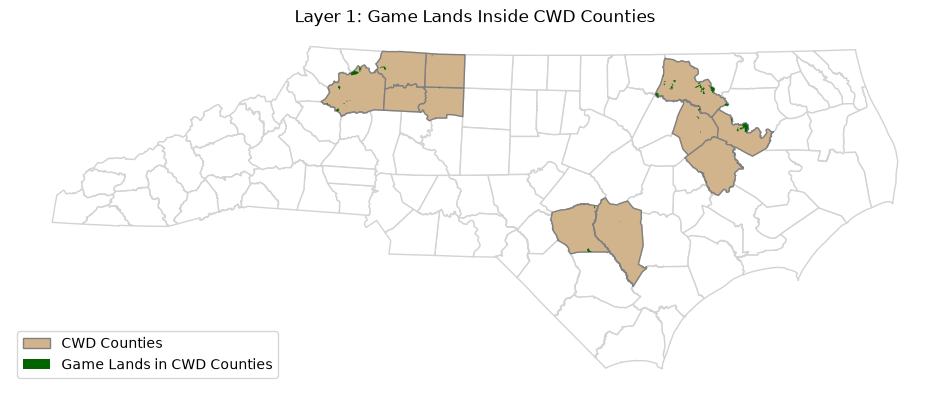

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
counties.plot(ax=ax, color="white", edgecolor="lightgray")
cwd_counties.plot(ax=ax, color="tan", edgecolor="gray")
gamelands_in_cwd.plot(ax=ax, color="darkgreen")

legend_items = [
    Patch(facecolor="tan", edgecolor="gray", label="CWD Counties"),
    Patch(facecolor="darkgreen", label="Game Lands in CWD Counties")
]
ax.legend(handles=legend_items, loc="lower left")
ax.set_title("Layer 1: Game Lands Inside CWD Counties")
ax.set_axis_off()
plt.show()

## Layer 2: Deer Sightings Near CWD-Zone Game Lands
**Question:** Where are people seeing deer within 5 miles of the game lands from Layer 1?

**Method:** Buffer and clip. I made a 5 mile buffer around the Layer 1 game lands, then used `gpd.clip()` to keep only the deer sightings inside that buffer. This builds on the results of Layer 1.

**Inputs:** Layer 1 (game lands in CWD counties) and the GBIF deer sightings

In [9]:
# 5 miles in feet, since EPSG:2264 uses feet
buffer_dist = 5 * 5280

cwd_buffer = gamelands_in_cwd.copy()
cwd_buffer["geometry"] = gamelands_in_cwd.buffer(buffer_dist)

# Keep only deer sightings inside the buffer
deer_near_cwd = gpd.clip(deer_gdf, cwd_buffer)
print(len(deer_near_cwd), "deer sightings within 5 miles of CWD-zone game lands")

27 deer sightings within 5 miles of CWD-zone game lands


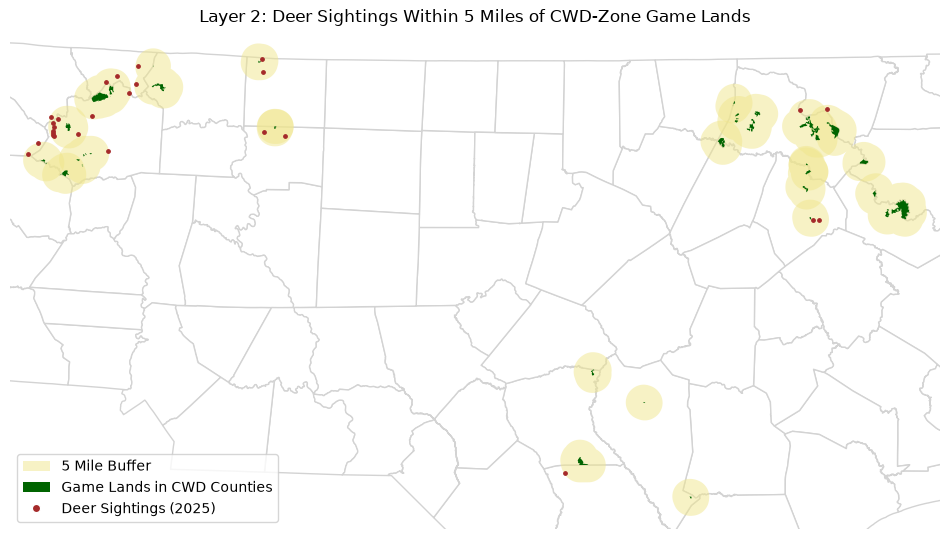

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
counties.plot(ax=ax, color="white", edgecolor="lightgray")
cwd_buffer.plot(ax=ax, color="khaki", alpha=0.5)
gamelands_in_cwd.plot(ax=ax, color="darkgreen")
deer_near_cwd.plot(ax=ax, color="brown", markersize=6)

# Zoom to the buffer area
minx, miny, maxx, maxy = cwd_buffer.total_bounds
ax.set_xlim(minx - 20000, maxx + 20000)
ax.set_ylim(miny - 20000, maxy + 20000)

legend_items = [
    Patch(facecolor="khaki", alpha=0.5, label="5 Mile Buffer"),
    Patch(facecolor="darkgreen", label="Game Lands in CWD Counties"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="brown",
           markersize=6, label="Deer Sightings (2025)")
]
ax.legend(handles=legend_items, loc="lower left")
ax.set_title("Layer 2: Deer Sightings Within 5 Miles of CWD-Zone Game Lands")
ax.set_axis_off()
plt.show()

## Layer 3: Game Lands Outside CWD Counties
**Question:** Which public hunting land is outside the CWD counties?

**Method:** Difference. I used `gpd.overlay()` with `how="difference"` to take all game lands and remove any parts that fall inside the CWD counties. What's left is game land with no CWD designation.

**Inputs:** NCWRC game lands and the CWD counties

In [11]:
gamelands_outside_cwd = gpd.overlay(game_lands, cwd_counties, how="difference")

# Compare total acreage (EPSG:2264 area is in square feet)
sqft_per_acre = 43560
acres_in = gamelands_in_cwd.area.sum() / sqft_per_acre
acres_out = gamelands_outside_cwd.area.sum() / sqft_per_acre
print(f"Game land acres in CWD counties: {acres_in:,.0f}")
print(f"Game land acres outside CWD counties: {acres_out:,.0f}")

Game land acres in CWD counties: 41,516
Game land acres outside CWD counties: 2,074,602


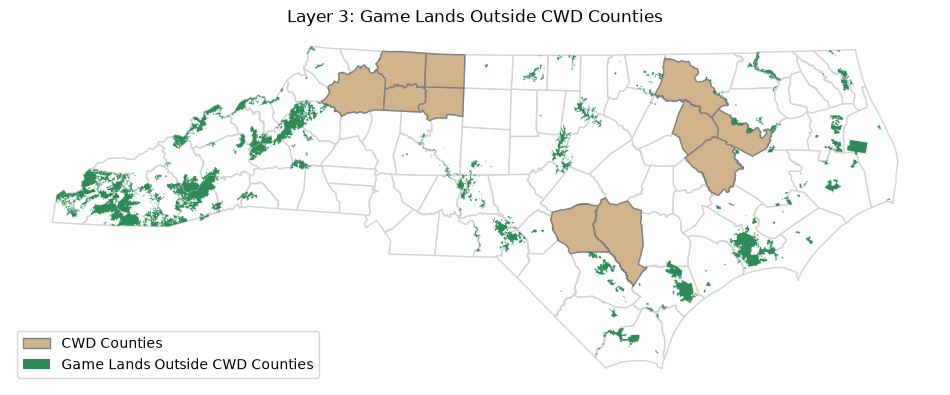

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
counties.plot(ax=ax, color="white", edgecolor="lightgray")
cwd_counties.plot(ax=ax, color="tan", edgecolor="gray")
gamelands_outside_cwd.plot(ax=ax, color="seagreen")

legend_items = [
    Patch(facecolor="tan", edgecolor="gray", label="CWD Counties"),
    Patch(facecolor="seagreen", label="Game Lands Outside CWD Counties")
]
ax.legend(handles=legend_items, loc="lower left")
ax.set_title("Layer 3: Game Lands Outside CWD Counties")
ax.set_axis_off()
plt.show()